# CHAPTER 4 损失函数

## 前言

> 在之前学习机器学习时，我们最先接触的例子——线性回归中，它一上来就使用 MSE（均方误差）作为其损失函数。我们在高中时就学过，这实际上就是用最小二乘法推导出的结果，所以我们可能就没有进一步提出疑问。
>
> 但是，在学习逻辑回归时，突然就出现了一个**交叉熵**的概念。这让我很是困惑，为什么不沿用线性回归中均方差的思想？而且在学习各种损失函数的时候，感觉这些函数看起来很像是被"凑"出来的——平方误差、交叉熵、soft max……它们之间有什么内在联系？
>
> 所以我就产生了一个很深的疑问——**损失函数到底是怎么被构造出来的？**
>
> 直到今天，在我看完 *Understanding Deep Learning*（UDL）的第五章以后，这个问题才终于被解决。UDL 给出了一种全新的视角：**从极大似然估计的角度出发，去理解和推导损失函数**。

> **本章参考**：
> - *Understanding Deep Learning* 
> - 知乎：<a href = "https://www.zhihu.com/question/281311791/answer/2343718429" >最大似然估计中的“似然”如何解释？</a>
> - 知乎：<a href = "https://www.zhihu.com/question/281311791/answer/2343718429" >最大似然估计和最小二乘法怎么理解？</a>

## 4.1 极大似然估计

在正式进入损失函数的推导之前，我们需要先掌握一个核心工具——**极大似然估计（Maximum Likelihood Estimation, MLE）**。

先从最直观的例子开始。

### 4.1.1 引例：掷硬币

假设你面前有三枚硬币，它们抛出正面的概率各不相同：

- 硬币 A：抛出正面的概率 $p_A = \frac{2}{5} = 0.4$
- 硬币 B：抛出正面的概率 $p_B = \frac{1}{2} = 0.5$
- 硬币 C：抛出正面的概率 $p_C = \frac{3}{5} = 0.6$

现在，我随机拿起其中**一枚**硬币（你不知道是哪一枚），抛了 $10$ 次，结果有 **$7$ 次正面朝上**。

**问题**：我手中拿的最有可能是哪枚硬币？

---

直觉上，你可能觉得"10次中7次正面"说明这枚硬币抛出正面的概率应该接近 $0.7$。三枚硬币中，硬币 C 的 $p_C=0.6$ 最接近 $0.7$，所以答案是硬币 C。

但我们怎么用数学的语言严谨地描述这个过程？让我们对每一枚硬币，分别计算"抛10次恰好出现7次正面"的概率：

对于一枚正面概率为 $p$ 的硬币，抛 $n=10$ 次出现 $k=7$ 次正面的概率服从**二项分布**：

$$P(k=7 \mid n=10, p) = \binom{10}{7} \cdot p^7 \cdot (1-p)^3$$

分别代入三枚硬币的 $p$ 值：

| 硬币 | $p$ | $P(\text{10次中7次正面})$ |
|:---:|:---:|:---:|
| A | $0.4$ | $\binom{10}{7} \times 0.4^7 \times 0.6^3 \approx 0.0425$ |
| B | $0.5$ | $\binom{10}{7} \times 0.5^7 \times 0.5^3 \approx 0.1172$ |
| C | $0.6$ | $\binom{10}{7} \times 0.6^7 \times 0.4^3 \approx 0.2150$ |

**结论**：硬币 C 产生"10次中7次正面"这个结果的概率最大（$0.2150$），因此它最有可能是我们手中的硬币。

---

这个例子看似简单，但其中蕴含的思想正是极大似然估计的核心：**既然这个结果已经发生了，那么使得这个结果出现概率最大的参数，就是最合理的参数估计。**

### 4.1.2 概率与似然

在深入 MLE 之前，我们必须先厘清两个极易混淆的核心概念：**概率（Probability）** 与 **似然（Likelihood）**。

---

#### 概率（Probability）

**概率**描述的是：**在参数已知的前提下，对不同结果出现的可能性进行度量。**

用数学语言说：给定确定的参数 $\theta$，数据 $x$ 出现的概率为 $P(x \mid \theta)$。这里的 $\theta$ 是**已知常量**，$x$ 是**变量**。

回到掷硬币的例子：已知硬币正面概率 $p=0.5$（参数固定），问抛10次恰好出现7次正面的概率是多少？这就是在**算概率**：

$$P(k=7 \mid n=10, p=0.5) = \binom{10}{7} \times 0.5^7 \times 0.5^3$$

---

#### 似然（Likelihood）

**似然**的思路恰好相反：**在已经观测到数据的前提下，反推什么样的参数最可能产生这组数据。**

用数学语言说：给定已经观测到的数据 $x$，参数 $\theta$ 的似然值为 $L(\theta \mid x)$。这里的数据 $x$ 是**已知常量**，$\theta$ 是**变量**。

回到掷硬币的例子：已经观测到"10次中出现7次正面"这个结果（数据固定），问什么样的 $p$ 值使得这个结果最可能发生？这就是在**算似然**：

$$L(p \mid n=10, k=7) = \binom{10}{7} \cdot p^7 \cdot (1-p)^3$$

这里 $p$ 是自变量，我们可以画出 $L(p)$ 随 $p$ 变化的曲线，找到使似然最大的 $p$。

> 注意：似然函数 $L(\theta \mid x)$ 和概率密度函数 $f(x; \theta)$ 在**形式上完全相同**（都是同一个公式），但**看待的角度截然不同**：
> - 作为 $x$ 的函数（$\theta$ 固定）→ 它是概率密度函数
> - 作为 $\theta$ 的函数（$x$ 固定）→ 它是似然函数
>
> 有些教材使用分号记号 $f(x; \theta)$ 来强调这一点：分号后面的是参数，分号前面的是数据。这种记法在极大似然的语境下尤为清晰——似然函数写作 $L(\theta) = \prod_{i=1}^{n} f(x_i; \theta)$，明确表示 $\theta$ 是变量，$x_i$ 是已知观测值。

---

下面我们画出掷硬币例子中，似然函数 $L(p)$ 随参数 $p$ 变化的曲线：

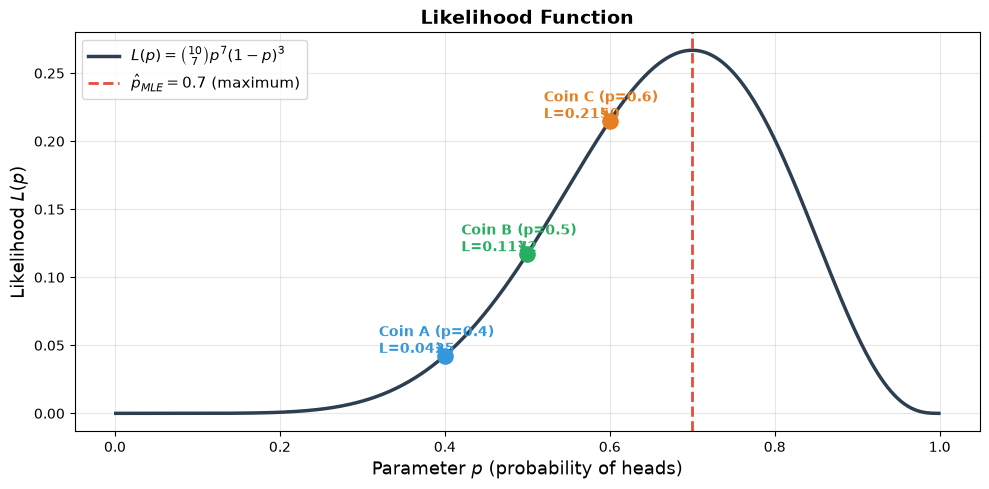

MLE estimate: p_hat = 0.7 (i.e., sample frequency k/n)
This matches intuition: 7 heads in 10 tosses -> the most reasonable estimate for p is 7/10 = 0.7


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb

# Experiment data: 10 tosses, 7 heads
n, k = 10, 7

# Compute likelihood over p in [0, 1]
p_range = np.linspace(0.001, 0.999, 500)
likelihood = comb(n, k) * (p_range ** k) * ((1 - p_range) ** (n - k))

# Find the maximum
p_mle = k / n  # theoretical maximum at p = k/n = 0.7

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(p_range, likelihood, '#2C3E50', linewidth=2.5, label=r'$L(p) = \binom{10}{7} p^7 (1-p)^3$')
ax.axvline(x=p_mle, color='#E74C3C', linestyle='--', linewidth=2,
           label=fr'$\hat{{p}}_{{MLE}} = {p_mle}$ (maximum)')

# Mark the three coins
coins = {'A': 0.4, 'B': 0.5, 'C': 0.6}
colors = ['#3498DB', '#27AE60', '#E67E22']
for (name, p_val), c in zip(coins.items(), colors):
    l_val = comb(n, k) * (p_val ** k) * ((1 - p_val) ** (n - k))
    ax.scatter([p_val], [l_val], c=c, s=120, zorder=5)
    ax.annotate(f'Coin {name} (p={p_val})\nL={l_val:.4f}',
                xy=(p_val, l_val), fontsize=10, fontweight='bold', color=c,
                xytext=(p_val - 0.08, l_val + 0.002),
                arrowprops=dict(arrowstyle='->', color=c, lw=1.5))

ax.set_xlabel(r'Parameter $p$ (probability of heads)', fontsize=13)
ax.set_ylabel(r'Likelihood $L(p)$', fontsize=13)
ax.set_title('Likelihood Function', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"MLE estimate: p_hat = {p_mle} (i.e., sample frequency k/n)")
print(f"This matches intuition: 7 heads in 10 tosses -> the most reasonable "
      f"estimate for p is 7/10 = {p_mle}")

### 4.1.3 极大似然估计的思想与形式化

从掷硬币的例子中，我们可以提炼出一个普适的思路：

> **给定一组观测数据，我们想知道什么样的参数 $\theta$ 最有可能产生这组数据。答案就是：使似然函数 $L(\theta)$ 取到最大值的那个 $\hat{\theta}$。**

这个想法和我们训练神经网络的目标是**不谋而合的**——我们有一组训练数据 $\{(x_i, y_i)\}$，有一个模型 $f(x; \phi)$（参数为 $\phi$），我们想要找到一组参数 $\phi$，使得模型对训练数据的"解释能力"最大。

---



#### 形式化定义

设有 $n$ 个**独立同分布**（i.i.d.）的样本 $x_1, x_2, \ldots, x_n$，它们来自某个概率分布，其概率密度函数（连续型）或分布律（离散型）为 $f(x; \theta)$，其中 $\theta$ 是未知参数。

**似然函数（Likelihood Function）** 定义为所有样本的联合概率密度：

$$
\boxed{L(\theta) = \prod_{i=1}^{n} f(x_i; \theta)}
$$

这里使用分号 $f(x; \theta)$ 而不是竖线 $f(x|\theta)$，是为了强调：**$\theta$ 是变量（未知参数），$x_i$ 是固定的（已知观测值）**。$\theta$ 不是一个随机变量，而是一个待估计的确定值。

> **为什么是连乘？** 因为样本之间是独立的，根据概率论，多个独立事件同时发生的概率等于各自概率的乘积：
> $$P(A \cap B) = P(A) \cdot P(B) \quad \text{（当 A 和 B 独立时）}$$
>
> 所以 $n$ 个独立样本的联合概率就是 $n$ 个单独概率的连乘积。

**极大似然估计量（MLE Estimator）** $\hat{\theta}_{\text{MLE}}$ 就是使似然函数取最大值的 $\theta$：

$$
\boxed{\hat{\theta}_{\text{MLE}} = \underset{\theta}{\arg\max} \; L(\theta) = \underset{\theta}{\arg\max} \prod_{i=1}^{n} f(x_i; \theta)}
$$

---




#### 为什么取对数？

在实际计算中，连乘会带来两个严重问题：

1. **数值下溢**：每个 $f(x_i; \theta)$ 都是小于 1 的概率值，$n$ 个这样的值相乘，结果会迅速趋近于 $0$，超出计算机的浮点精度
2. **求导困难**：连乘的导数计算非常繁琐（需要用到乘法法则展开）

**解决方案**：取对数。因为 $\log$ 是单调递增函数，不改变极值点的位置（见图 5.2）。

由此得到**对数似然函数（Log-Likelihood Function）**：

$$
\boxed{\ell(\theta) = \log L(\theta) = \log \prod_{i=1}^{n} f(x_i; \theta) = \sum_{i=1}^{n} \log f(x_i; \theta)}
$$

因此 MLE 的求解等价于：

$$
\hat{\theta}_{\text{MLE}} = \underset{\theta}{\arg\max} \; \ell(\theta) = \underset{\theta}{\arg\max} \sum_{i=1}^{n} \log f(x_i; \theta)
$$

> **注意**：在机器学习中，我们习惯**最小化**损失函数而不是最大化。因此将最大化对数似然取负号，转化为**最小化负对数似然（Negative Log-Likelihood, NLL）**：
>
> $$\hat{\theta}_{\text{MLE}} = \underset{\theta}{\arg\min} \; \Big[-\sum_{i=1}^{n} \log f(x_i; \theta)\Big]$$
>
> 这就是损失函数的形式！后面我们会反复看到这个模式。

### 4.1.4 极大似然估计的求解步骤

总结起来，MLE 的求解分为以下四个步骤：

| 步骤 | 操作 | 说明 |
|:---:|:---|:---|
| **1** | **写出似然函数** | 根据数据的概率分布，写出联合概率 $L(\theta) = \prod_{i=1}^{n} f(x_i; \theta)$ |
| **2** | **取对数** | 得到对数似然 $\ell(\theta) = \sum_{i=1}^{n} \log f(x_i; \theta)$ |
| **3** | **求导数** | 对 $\ell(\theta)$ 关于 $\theta$ 求偏导，令 $\frac{\partial \ell}{\partial \theta} = 0$，得到似然方程 |
| **4** | **解方程** | 解出 $\hat{\theta}$，即为极大似然估计值 |

> **注意**：当似然函数不可导时（如均匀分布），需要根据具体情况直接分析似然函数的最大值点，不能直接套用求导步骤。

---

## 4.2 从极大似然推导线性回归的损失函数

### 4.2.1 问题设定

考虑一个标准的线性回归问题。我们有 $n$ 个训练样本 $\{(\mathbf{x}_1, y_1), (\mathbf{x}_2, y_2), \ldots, (\mathbf{x}_n, y_n)\}$，其中：

- $\mathbf{x}_i \in \mathbb{R}^d$：第 $i$ 个样本的输入特征向量（$d$ 维）
- $y_i \in \mathbb{R}$：第 $i$ 个样本的目标值（标量）

我们用一个线性模型来拟合数据：

$$f(\mathbf{x}_i; \mathbf{w}) = \mathbf{w}^T \mathbf{x}_i$$

其中 $\mathbf{w} \in \mathbb{R}^d$ 是模型的权重参数（为简化记号，这里省略了偏置项 $b$，可以将其吸收进 $\mathbf{w}$ 和 $\mathbf{x}$ 中——在 $\mathbf{x}$ 末尾补一个常数 $1$ 即可）。

### 4.2.2 高斯噪声假设

在现实世界中，我们的线性模型 $\mathbf{w}^T \mathbf{x}_i$ 不可能完美地拟合每一个数据点。真实值 $y_i$ 和预测值 $\mathbf{w}^T \mathbf{x}_i$ 之间总会存在一个偏差——我们称之为**噪声**或**误差**。

我们不再是简单地"让预测值逼近真实值"，而是换一个角度：**对误差的分布做出概率假设**。

具体地，我们假设每个样本的误差 $\epsilon_i = y_i - \mathbf{w}^T \mathbf{x}_i$ 服从**均值为 0、方差为 $\sigma^2$ 的正态分布**：

$$\epsilon_i = y_i - \mathbf{w}^T \mathbf{x}_i \sim \mathcal{N}(0, \sigma^2)$$

这个假设意味着什么？

- **均值为 0**：误差在正负两个方向上是"公平"的——模型不会系统性地高估或低估
- **方差 $\sigma^2$ 恒定**（同方差假设 / homoscedasticity）：每个样本点的噪声大小是相同的

在给定输入 $\mathbf{x}_i$ 和参数 $\mathbf{w}$ 的条件下，目标值 $y_i$ 的条件分布为：

$$y_i \mid \mathbf{x}_i; \mathbf{w} \sim \mathcal{N}(\mathbf{w}^T \mathbf{x}_i,\; \sigma^2)$$

即：**在给定 $\mathbf{x}_i$ 的条件下，$y_i$ 服从均值为 $\mathbf{w}^T \mathbf{x}_i$、方差为 $\sigma^2$ 的正态分布。**

<img src="../attachment/图4-1.jpg" width="700" style="display: block; margin: 0 auto;" >


> 如图，中间那条绿色的线（$ \mathbf{w}^T \mathbf{x}_i $）就是就是服从的正态分布的均值，由于方差固定，我们看到构造出相同的，以绿线为中心的正态分布曲线。

其概率密度函数为：

$$\boxed{f(y_i \mid \mathbf{x}_i; \mathbf{w}, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left\{-\frac{(y_i - \mathbf{w}^T \mathbf{x}_i)^2}{2\sigma^2}\right\}}$$

> **这里 $\mathbf{w}$ 是我们想要求解的未知参数**，$\sigma^2$ 暂时视为已知常数（后面会说明它不影响最终结果）。分号后面的 $\mathbf{w}$ 和 $\sigma^2$ 是变量，分号前面的 $y_i$ 和 $\mathbf{x}_i$ 是已知观测值

### 4.2.3 构建似然函数

假设 $n$ 个样本是**独立**的（这是极大似然估计的关键前提），则似然函数为各样本条件概率密度的连乘积：

$$
\boxed{L(\mathbf{w}) = \prod_{i=1}^{n} f(y_i \mid \mathbf{x}_i; \mathbf{w}, \sigma^2) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left\{-\frac{(y_i - \mathbf{w}^T \mathbf{x}_i)^2}{2\sigma^2}\right\}}
$$

> **注意**：这里 $\mathbf{w}$ 是变量（我们要找的），$\{(\mathbf{x}_i, y_i)\}$ 是已知数据。这正对应于 4.1 节中强调的"似然"视角——数据固定，参数可变。

---

### 4.2.4 从极大似然到最小二乘

接下来取对数，将连乘转化为连加：

$$
\begin{aligned}
\ell(\mathbf{w}) = \log L(\mathbf{w}) &= \sum_{i=1}^{n} \log\left[\frac{1}{\sqrt{2\pi\sigma^2}} \exp\left\{-\frac{(y_i - \mathbf{w}^T \mathbf{x}_i)^2}{2\sigma^2}\right\}\right] \\[6pt]
&= \sum_{i=1}^{n} \left[\log\frac{1}{\sqrt{2\pi\sigma^2}} - \frac{(y_i - \mathbf{w}^T \mathbf{x}_i)^2}{2\sigma^2}\right] \\[6pt]
&= -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^{n} (y_i - \mathbf{w}^T \mathbf{x}_i)^2
\end{aligned}
$$

---

**关键一步**：现在我们要找到 $\hat{\mathbf{w}}_{\text{MLE}}$，使得对数似然 $\ell(\mathbf{w})$ 最大化：

$$\hat{\mathbf{w}}_{\text{MLE}} = \underset{\mathbf{w}}{\arg\max} \; \ell(\mathbf{w})$$

观察 $\ell(\mathbf{w})$ 的结构：
- 第一项 $-\frac{n}{2}\log(2\pi\sigma^2)$ 与 $\mathbf{w}$ **无关**，可以去掉
- 第二项 $-\frac{1}{2\sigma^2}\sum_{i=1}^{n} (y_i - \mathbf{w}^T \mathbf{x}_i)^2$ 中，因子 $-\frac{1}{2\sigma^2}$ 是负的常数，**不影响极值点位置**

因此：

$$
\begin{aligned}
\hat{\mathbf{w}}_{\text{MLE}} &= \underset{\mathbf{w}}{\arg\max} \; \left[-\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^{n} (y_i - \mathbf{w}^T \mathbf{x}_i)^2\right] \\[6pt]
&= \underset{\mathbf{w}}{\arg\max} \; \left[-\sum_{i=1}^{n} (y_i - \mathbf{w}^T \mathbf{x}_i)^2\right] \\[6pt]
&= \underset{\mathbf{w}}{\arg\min} \; \sum_{i=1}^{n} (y_i - \mathbf{w}^T \mathbf{x}_i)^2
\end{aligned}
$$

---

**我们得到了什么？**

$$
\boxed{\hat{\mathbf{w}}_{\text{MLE}} = \underset{\mathbf{w}}{\arg\min} \sum_{i=1}^{n} \big(y_i - \mathbf{w}^T \mathbf{x}_i\big)^2}
$$

取均值后就是我们熟知的 **MSE（Mean Squared Error）**：

$$\boxed{\mathcal{L}(\mathbf{w}) = \frac{1}{n}\sum_{i=1}^{n} \big(y_i - \mathbf{w}^T \mathbf{x}_i\big)^2}$$

> 在线性回归中，MSE 损失函数**不是凭空捏造的**，它来自于三个假设：
>
> 1. **误差服从正态分布**：$\epsilon \sim \mathcal{N}(0, \sigma^2)$
> 2. **样本独立同分布**（i.i.d.）
> 3. **极大似然估计**：寻找让数据出现概率最大的参数
>
> 在这三个前提下，最大化似然**等价于**最小化平方误差。这就是 MSE 作为线性回归损失函数的**概率论基础**。

### 4.2.5 异方差（Heteroscedasticity）：当方差不再是常数

在 4.2.2 节中，我们做了一个重要假设：所有样本的噪声 $\epsilon_i$ 拥有**相同的方差** $\sigma^2$（同方差假设 / homoscedasticity）。也就是说，无论输入 $\mathbf{x}_i$ 取什么值，模型预测的不确定性都是一样的。

但在现实世界中，这个假设往往不成立。例如：

- 预测房价时，高价房产的价格波动远大于低价房产
- 预测收入时，高收入人群的收入方差远大于低收入人群
- 物理测量中，传感器的精度可能随被测值的增大而降低

**异方差**（heteroscedasticity）就是指：**噪声的方差 $\sigma^2$ 依赖于输入 $\mathbf{x}$，即 $\sigma^2 = \sigma^2(\mathbf{x})$。**

下面我们用一个简单的线性回归例子来直观感受同方差和异方差的区别。


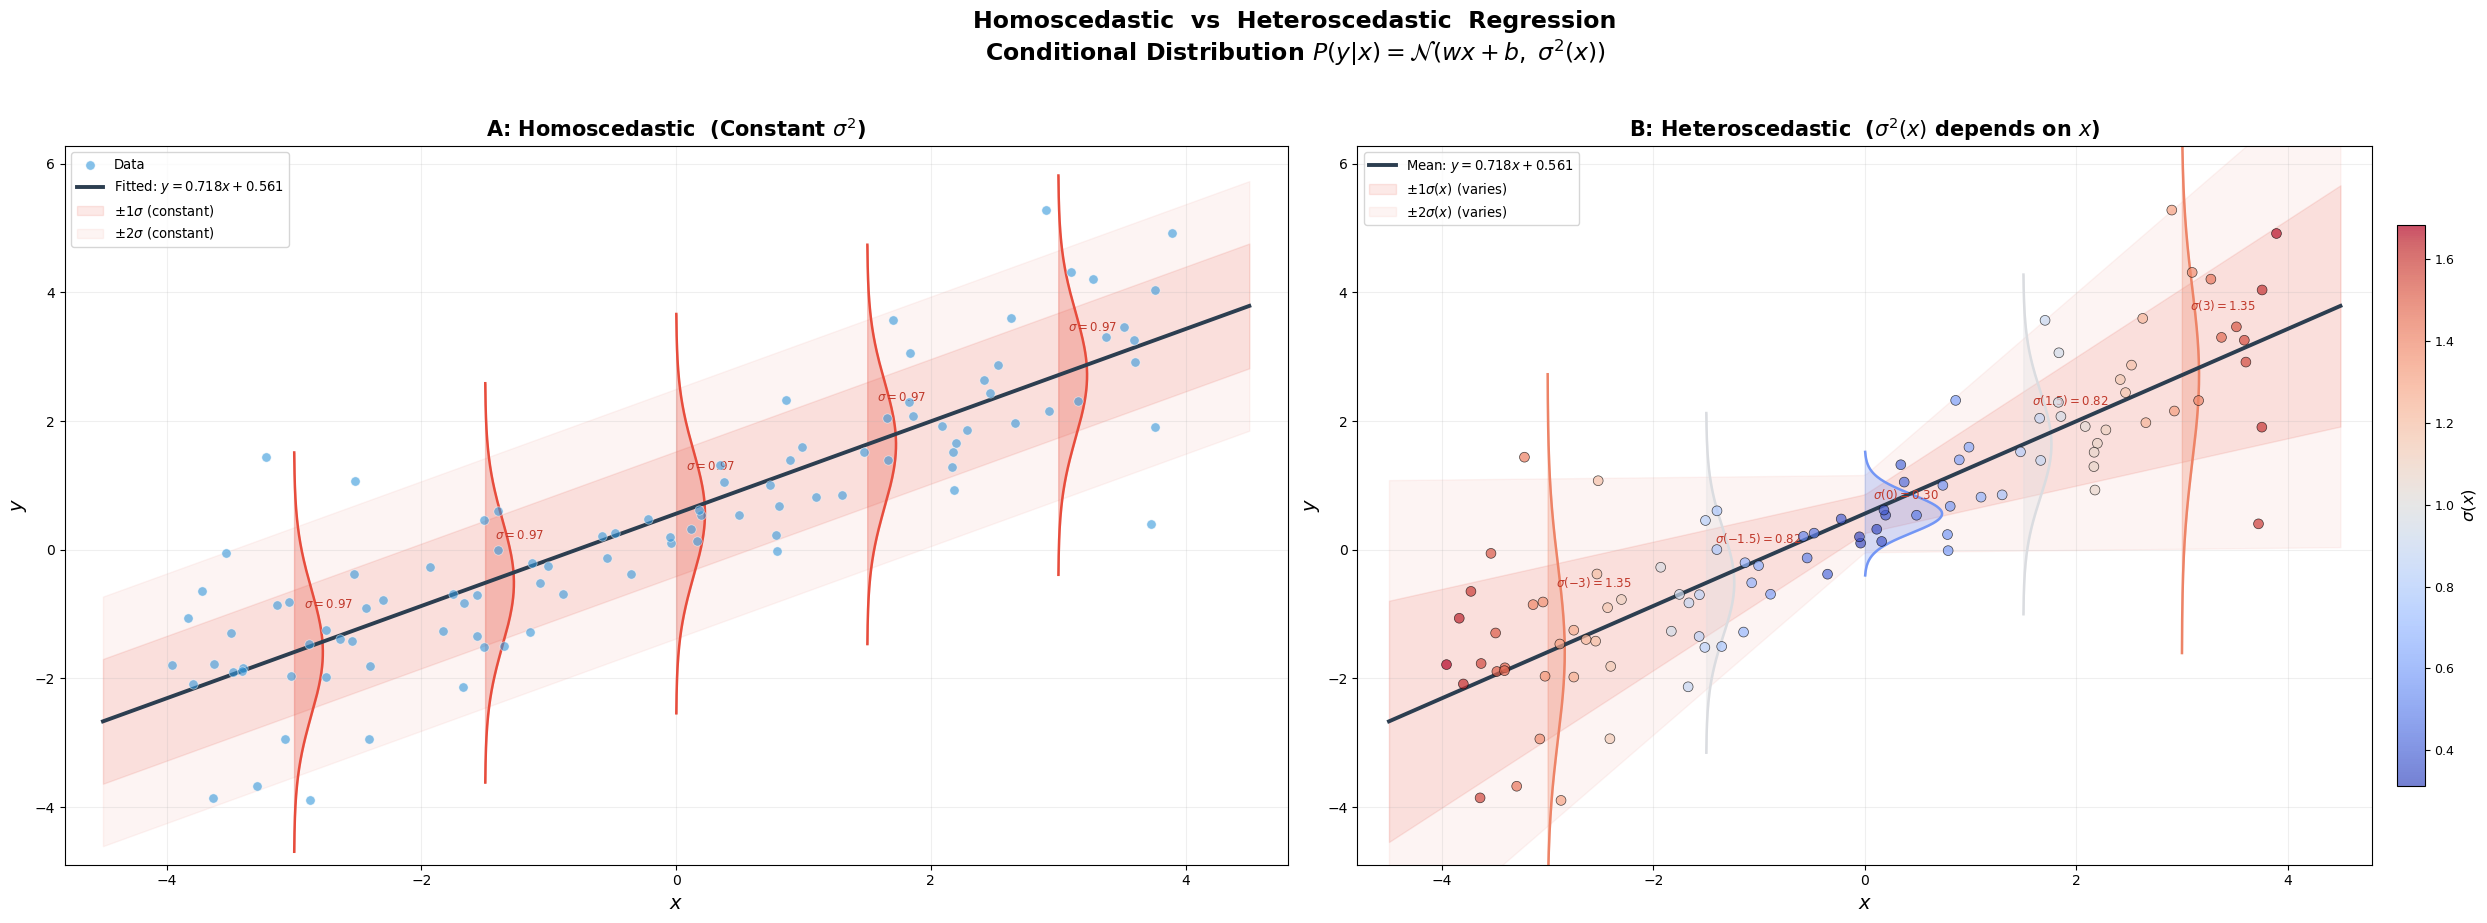

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

# --- 生成异方差数据 ---
n = 100
x = np.random.uniform(-4, 4, n)
w_true, b_true = 0.8, 0.5

# 异方差噪声: σ(x) 随 |x| 增大 —— x 越远离原点, 噪声越大
sigma_x = 0.3 + 0.35 * np.abs(x)
noise = np.random.randn(n) * sigma_x
y = w_true * x + b_true + noise

# --- 拟合直线 (不考虑异方差的简单最小二乘) ---
w_fit, b_fit = np.polyfit(x, y, 1)

fig, axes = plt.subplots(1, 2, figsize=(26, 9))

# ========================
# Panel A: 同方差假设 (常量 σ²)
# ========================
ax = axes[0]
sigma_const = np.std(y - (w_fit * x + b_fit))  # 用残差标准差作为"同方差 σ"

ax.scatter(x, y, c='#3498DB', s=45, alpha=0.6, edgecolors='white',
           linewidth=0.5, zorder=5, label='Data')

# 拟合直线
x_line = np.linspace(-4.5, 4.5, 300)
y_line = w_fit * x_line + b_fit
ax.plot(x_line, y_line, '#2C3E50', linewidth=2.8, zorder=3,
        label=fr'Fitted: $y = {w_fit:.3f}x + {b_fit:.3f}$')

# 同方差: 绘制等宽的 1σ、2σ 带
ax.fill_between(x_line,
                y_line - sigma_const, y_line + sigma_const,
                alpha=0.12, color='#E74C3C', label=r'$\pm 1\sigma$ (constant)')
ax.fill_between(x_line,
                y_line - 2*sigma_const, y_line + 2*sigma_const,
                alpha=0.06, color='#E74C3C', label=r'$\pm 2\sigma$ (constant)')

# 在选定 x 位置绘制等宽度的高斯截面
x_demo = [-3, -1.5, 0, 1.5, 3]
for xp in x_demo:
    yp = w_fit * xp + b_fit
    y_vals = np.linspace(yp - 3.2*sigma_const, yp + 3.2*sigma_const, 150)
    pdf_vals = norm.pdf(y_vals, yp, sigma_const)
    # 水平缩放: 将 PDF 值映射到 x 轴的可见宽度
    h_scale = 0.55
    x_curve = xp + pdf_vals * h_scale
    ax.fill_betweenx(y_vals, xp, x_curve, alpha=0.28, color='#E74C3C')
    ax.plot(x_curve, y_vals, '#E74C3C', linewidth=1.8)
    # 标注 σ 值
    ax.annotate(rf'$\sigma={sigma_const:.2f}$',
                xy=(xp + 0.08, yp + sigma_const * 0.7),
                fontsize=8.5, color='#C0392B', fontweight='bold')

ax.set_xlabel('$x$', fontsize=14); ax.set_ylabel('$y$', fontsize=14)
ax.set_title('A: Homoscedastic  (Constant $\sigma^2$)', fontsize=15, fontweight='bold')
ax.legend(fontsize=9.5, loc='upper left')
ax.set_xlim(-4.8, 4.8); ax.set_ylim(y.min() - 1, y.max() + 1)
ax.grid(True, alpha=0.2)

# ========================
# Panel B: 异方差 (σ² 随 x 变化)
# ========================
ax = axes[1]

# 用颜色编码局部方差
sc = ax.scatter(x, y, c=sigma_x, cmap='coolwarm', s=50, alpha=0.7,
                edgecolors='black', linewidth=0.5, zorder=5)
cbar = plt.colorbar(sc, ax=ax, shrink=0.78, pad=0.02)
cbar.set_label(r'$\sigma(x)$', fontsize=12)
cbar.ax.tick_params(labelsize=9)

# 同一根拟合直线 (均值)
ax.plot(x_line, y_line, '#2C3E50', linewidth=2.8, zorder=3,
        label=fr'Mean: $y = {w_fit:.3f}x + {b_fit:.3f}$')

# 异方差: 变化的 1σ 带 (宽度随 |x| 增大)
sigma_line = 0.3 + 0.35 * np.abs(x_line)
ax.fill_between(x_line,
                y_line - sigma_line, y_line + sigma_line,
                alpha=0.12, color='#E74C3C', label=r'$\pm 1\sigma(x)$ (varies)')
ax.fill_between(x_line,
                y_line - 2*sigma_line, y_line + 2*sigma_line,
                alpha=0.06, color='#E74C3C', label=r'$\pm 2\sigma(x)$ (varies)')

# 在同样 5 个位置绘制宽度不同的高斯截面
for xp in x_demo:
    yp = w_fit * xp + b_fit
    sigma_p = 0.3 + 0.35 * abs(xp)
    y_vals = np.linspace(yp - 3.2*sigma_p, yp + 3.2*sigma_p, 150)
    pdf_vals = norm.pdf(y_vals, yp, sigma_p)
    h_scale = 0.55
    x_curve = xp + pdf_vals * h_scale

    # 根据方差大小使用不同颜色
    curve_color = plt.cm.coolwarm(sigma_p / sigma_x.max())
    ax.fill_betweenx(y_vals, xp, x_curve, alpha=0.28, color=curve_color)
    ax.plot(x_curve, y_vals, color=curve_color, linewidth=1.8)
    # 标注变化的 σ
    ax.annotate(rf'$\sigma({xp})={sigma_p:.2f}$',
                xy=(xp + 0.08, yp + sigma_p * 0.75),
                fontsize=8.5, color='#C0392B', fontweight='bold')

ax.set_xlabel('$x$', fontsize=14); ax.set_ylabel('$y$', fontsize=14)
ax.set_title('B: Heteroscedastic  ($\sigma^2(x)$ depends on $x$)',
             fontsize=15, fontweight='bold')
ax.legend(fontsize=9.5, loc='upper left')
ax.set_xlim(-4.8, 4.8); ax.set_ylim(y.min() - 1, y.max() + 1)
ax.grid(True, alpha=0.2)
fig.suptitle('Homoscedastic  vs  Heteroscedastic  Regression\n'
             r'Conditional Distribution $P(y|x) = \mathcal{N}(wx+b,\; \sigma^2(x))$',
             fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.2.6 异方差下的极大似然推导

有了上面的直观感受，我们现在从数学上严格推导：**当方差 $\sigma^2$ 依赖于输入 $\mathbf{x}$ 时，极大似然估计会给出什么样的损失函数？**

---

#### 模型设定

在异方差假设下，条件分布变为：

$$
y_i \mid \mathbf{x}_i; \mathbf{w} \sim \mathcal{N}\big(\mathbf{w}^\top \mathbf{x}_i,\; \sigma_i^2\big),\qquad \sigma_i^2 = \sigma^2(\mathbf{x}_i)
$$

即每个样本有自己的方差 $\sigma_i^2$——它可以是 $\mathbf{x}_i$ 的任意函数。概率密度函数为：

$$
\boxed{f(y_i \mid \mathbf{x}_i; \mathbf{w}, \sigma_i^2) = \frac{1}{\sqrt{2\pi\sigma_i^2}} \exp\left\{-\frac{(y_i - \mathbf{w}^\top \mathbf{x}_i)^2}{2\sigma_i^2}\right\}}
$$

> **与同方差的关键区别**：分母中的 $\sigma_i^2$ 现在带了下标 $i$——它随样本不同而变化，**不能**被提到连加号外面。



---

#### 构建似然函数

假设样本独立，似然函数为：

$$
L(\mathbf{w}) = \prod_{i=1}^{n} f(y_i \mid \mathbf{x}_i; \mathbf{w}, \sigma_i^2)
              = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma_i^2}} \exp\left\{-\frac{(y_i - \mathbf{w}^\top \mathbf{x}_i)^2}{2\sigma_i^2}\right\}
$$

取对数：

$$
\begin{aligned}
\ell(\mathbf{w}) = \log L(\mathbf{w})
&= \sum_{i=1}^{n} \log\left[\frac{1}{\sqrt{2\pi\sigma_i^2}} \exp\left\{-\frac{(y_i - \mathbf{w}^\top \mathbf{x}_i)^2}{2\sigma_i^2}\right\}\right] \\[6pt]
&= \sum_{i=1}^{n} \left[\log\frac{1}{\sqrt{2\pi\sigma_i^2}} - \frac{(y_i - \mathbf{w}^\top \mathbf{x}_i)^2}{2\sigma_i^2}\right] \\[6pt]
&= -\frac{1}{2}\sum_{i=1}^{n}\log(2\pi\sigma_i^2) - \sum_{i=1}^{n} \frac{(y_i - \mathbf{w}^\top \mathbf{x}_i)^2}{2\sigma_i^2}
\end{aligned}
$$

---



#### 从极大似然到加权最小二乘

现在最大化对数似然：

$$
\hat{\mathbf{w}}_{\text{MLE}} = \underset{\mathbf{w}}{\arg\max} \; \ell(\mathbf{w})
$$

观察 $\ell(\mathbf{w})$：第一项 $-\frac{1}{2}\sum\log(2\pi\sigma_i^2)$ 与 $\mathbf{w}$ **无关**（假设 $\sigma_i^2$ 已知或已估计），去掉不影响极值点。

第二项取负号后转化为最小化：

$$
\boxed{\hat{\mathbf{w}}_{\text{MLE}} = \underset{\mathbf{w}}{\arg\min} \sum_{i=1}^{n} \frac{(y_i - \mathbf{w}^\top \mathbf{x}_i)^2}{\sigma_i^2}}
$$

这就是**加权最小二乘（Weighted Least Squares, WLS）**：

$$
\boxed{\mathcal{L}_{\text{hetero}}(\mathbf{w}) = \sum_{i=1}^{n} \frac{1}{\sigma_i^2} \big(y_i - \mathbf{w}^\top \mathbf{x}_i\big)^2}
$$

---



#### 对比与解读

| 假设 | 损失函数 | 权重 |
|:---|:---|:---|
| **同方差** $\sigma_i^2 = \sigma^2$ | $\displaystyle\sum_{i=1}^{n} (y_i - \mathbf{w}^\top \mathbf{x}_i)^2$ | 所有点等权 $w_i = 1$ |
| **异方差** $\sigma_i^2 = \sigma^2(\mathbf{x}_i)$ | $\displaystyle\sum_{i=1}^{n} \frac{(y_i - \mathbf{w}^\top \mathbf{x}_i)^2}{\sigma_i^2}$ | 权重 $w_i = 1/\sigma_i^2$ |

> **核心直觉**：
>
> - $\sigma_i^2$ **大**（该点噪声大、不可靠）→ 权重 $1/\sigma_i^2$ **小** → 该点在损失中的贡献被**压低**
> - $\sigma_i^2$ **小**（该点噪声小、精确）→ 权重 $1/\sigma_i^2$ **大** → 该点在损失中的贡献被**放大**
>
> 直观理解：**我们对"精确"的测量结果给予更多信任，对"模糊"的测量结果给予更少的信任。** 这比"一刀切"地平等对待所有点要合理得多。


---

#### 拓展：当 $\sigma^2(\mathbf{x})$ 也需要学习时

在深度学习中，一个更强大的做法是**让模型同时输出均值 $\mu(\mathbf{x})$ 和方差 $\sigma^2(\mathbf{x})$**。此时网络的输出是一个二维向量 $[\mu_i, \sigma_i^2]$，负对数似然损失为：

$$
\mathcal{L}_{\text{NLL}} = \sum_{i=1}^{n} \left[\frac{(y_i - \mu_i)^2}{2\sigma_i^2} + \frac{1}{2}\log\sigma_i^2\right] + \text{const}
$$

- 第一项 $\frac{(y_i - \mu_i)^2}{2\sigma_i^2}$：加权残差——方差大时惩罚小
- 第二项 $\frac{1}{2}\log\sigma_i^2$：**正则化项**——防止模型为了逃避惩罚而把方差推到无穷大

> 这个形式在 *Understanding Deep Learning* 第 5.3 节有详细讨论。它的一个关键应用是**不确定性估计**（uncertainty estimation）：模型不仅告诉你"预测值是多少"，还告诉你"对预测有多确定"。